# Tri-modal Coherence → LLM Quality Prediction
### 500-Prompt Evaluation: Which approach best predicts Gemini judge ratings?

Three approaches compared:
- **Approach 1 — WTSAS**: Quality-weighted alignment score (r = 0.0763)
- **Approach 2 — Naive Bayes LOO**: P(Good) via leave-one-out CV (r = 0.1931)
- **Approach 3 — Likelihood Ratio LOO**: log P(Good/Rest) via LOO CV (r = 0.2047) ⭐ Best

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch

sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.facecolor": "#161c2c",
    "figure.facecolor": "#0d1117",
    "axes.edgecolor": "#2a3554",
    "axes.labelcolor": "#dde4f5",
    "xtick.color": "#7b8db5",
    "ytick.color": "#7b8db5",
    "text.color": "#dde4f5",
    "grid.color": "#2a3554",
    "grid.linewidth": 0.5,
})

C1   = "#8fa5d0"   # WTSAS
C2   = "#3db8e0"   # Naive Bayes
C3   = "#2ee8a0"   # Likelihood Ratio (winner)
FEAT = "#7b8db5"   # individual features

df = pd.read_csv("results/final_3approaches.csv")
print(f"Loaded {len(df)} rows")
df.head(3)

Loaded 500 rows


,prompt_id,prompt,q_text,q_image,q_audio,judge_mean,judge_grade,nb_p_good_loo,lr_gr_loo,s1_text_image,s2_text_audio,s3_image_audio,tsas,wtsas_final
0,1,A fox exploring a cave in a snowy village,0.839816,0.472127,0.862416,4.25,0.8125,0.3050,0.6458,0.4255,0.0647,0.0411,0.1771,0.1010
1,2,A flamingo blacksmith exploring a cave,0.836263,0.436094,0.881909,3.00,0.5000,0.2756,0.5987,0.4348,-0.0212,0.0271,0.1469,0.0644
2,3,A mantis sailing a paper boat on a wooden bridge,0.841654,0.449645,0.861195,3.00,0.5000,0.2665,0.5833,0.4361,0.0620,0.0254,0.1745,0.0963


## Pearson r for each approach

In [14]:
judge = df["judge_mean"].values
wtsas = df["wtsas_final"].values
nb    = df["nb_p_good_loo"].values
lr    = df["lr_gr_loo"].values

r_wtsas, p_wtsas = stats.pearsonr(judge, wtsas)
r_nb,    p_nb    = stats.pearsonr(judge, nb)
r_lr,    p_lr    = stats.pearsonr(judge, lr)

summary = pd.DataFrame({
    "Approach": ["WTSAS [A1]", "Naive Bayes LOO [A2]", "Likelihood Ratio LOO [A3]"],
    "Pearson r": [r_wtsas, r_nb, r_lr],
    "p-value":   [p_wtsas, p_nb, p_lr],
    "Pairwise accuracy": [0.5 + np.arcsin(r)/np.pi for r in [r_wtsas, r_nb, r_lr]]
})
summary.style.highlight_max(subset=["Pearson r", "Pairwise accuracy"], color="#0db87a44")

,Approach,Pearson r,p-value,Pairwise accuracy
0,WTSAS [A1],0.076320,0.088237,0.524317
1,Naive Bayes LOO [A2],0.162012,0.000275,0.551798
2,Likelihood Ratio LOO [A3],0.160367,0.000318,0.551268


## Scatter plots: Predicted score vs. Judge rating

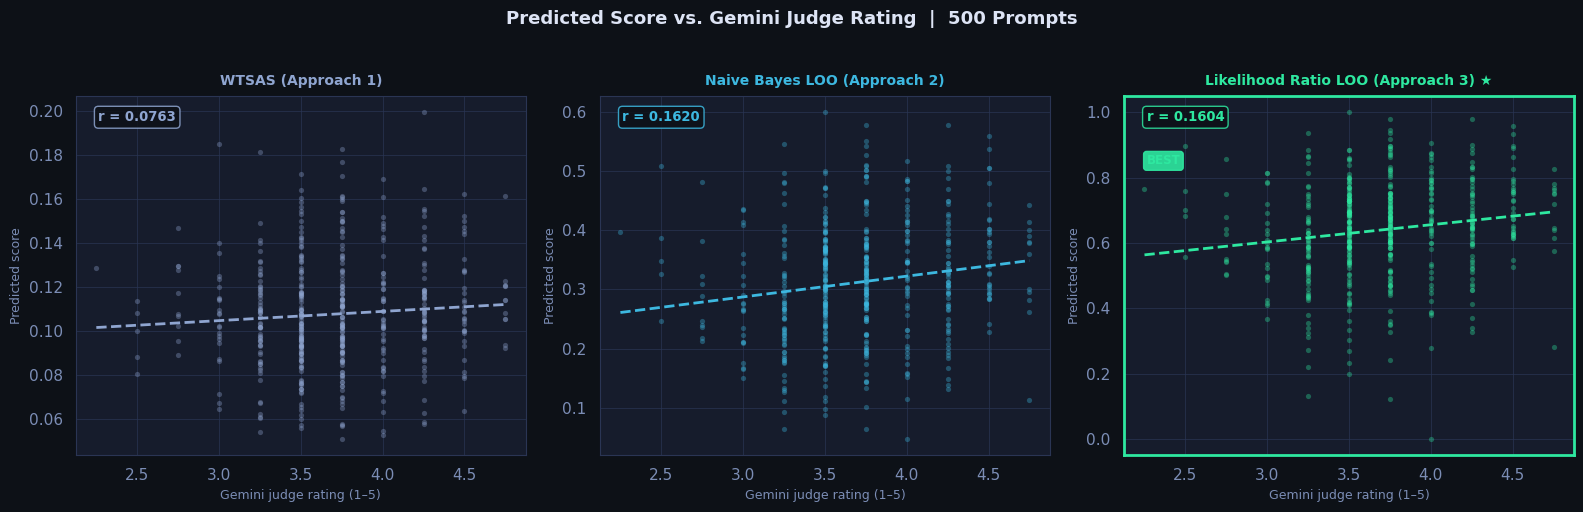

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor="#0d1117")
fig.suptitle("Predicted Score vs. Gemini Judge Rating  |  500 Prompts",
             fontsize=13, color="#dde4f5", fontweight="bold", y=1.02)

approaches = [
    ("WTSAS (Approach 1)",              wtsas, C1,   r_wtsas),
    ("Naive Bayes LOO (Approach 2)",    nb,    C2,   r_nb),
    ("Likelihood Ratio LOO (Approach 3) ★", lr, C3, r_lr),
]

for ax, (title, y, color, r) in zip(axes, approaches):
    ax.set_facecolor("#161c2c")

    ax.scatter(judge, y, color=color, alpha=0.35, s=14, linewidths=0)

    m, b = np.polyfit(judge, y, 1)
    x_line = np.linspace(judge.min(), judge.max(), 200)
    ax.plot(x_line, m * x_line + b, color=color, linewidth=2, linestyle="--")

    is_winner = color == C3
    for spine in ax.spines.values():
        spine.set_edgecolor(C3 if is_winner else "#2a3554")
        spine.set_linewidth(2 if is_winner else 0.8)

    ax.set_title(title, fontsize=10, color=color, fontweight="bold", pad=8)
    ax.set_xlabel("Gemini judge rating (1–5)", fontsize=9, color="#7b8db5")
    ax.set_ylabel("Predicted score", fontsize=9, color="#7b8db5")

    ax.text(0.05, 0.93, f"r = {r:.4f}", transform=ax.transAxes,
            fontsize=9.5, color=color, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#0d1117",
                      edgecolor=color, alpha=0.85))
    if is_winner:
        ax.text(0.05, 0.81, "BEST", transform=ax.transAxes,
                fontsize=8.5, color=C3, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.25", facecolor=C3+"22",
                          edgecolor=C3, alpha=0.9))

plt.tight_layout()
plt.savefig("results/scatter_plots.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

## Bar chart: All metrics vs. Gemini judge

Quality composite (r-weighted) r = 0.2027  ← reference: quality alone, no coherence


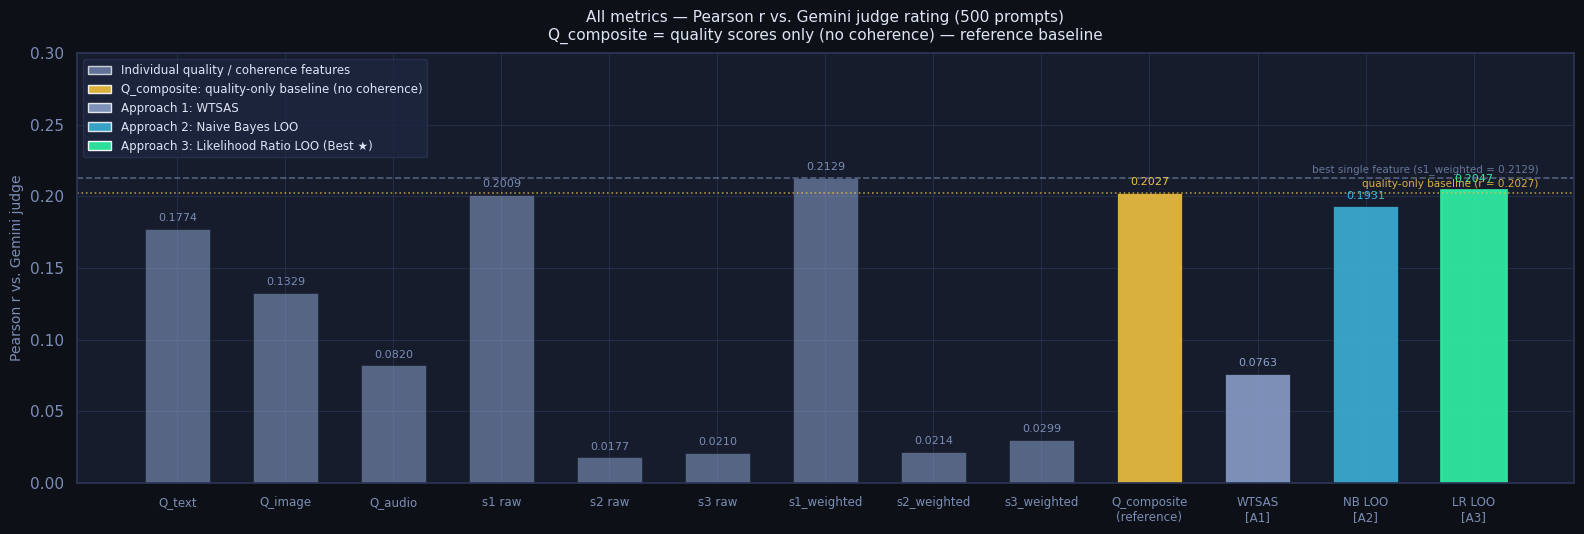

In [16]:
# --- Compute reference: quality composite (r-weighted) ---
r_qt, _ = stats.pearsonr(judge, df["q_text"])
r_qi, _ = stats.pearsonr(judge, df["q_image"])
r_qa, _ = stats.pearsonr(judge, df["q_audio"])
q_composite = (r_qt*df["q_text"] + r_qi*df["q_image"] + r_qa*df["q_audio"]) / (r_qt+r_qi+r_qa)
r_qcomp, _  = stats.pearsonr(judge, q_composite)
print(f"Quality composite (r-weighted) r = {r_qcomp:.4f}  ← reference: quality alone, no coherence")

CREF = "#f0c040"   # reference colour

bar_labels = [
    "Q_text", "Q_image", "Q_audio",
    "s1 raw", "s2 raw", "s3 raw",
    "s1_weighted", "s2_weighted", "s3_weighted",
    "Q_composite\n(reference)", "WTSAS\n[A1]", "NB LOO\n[A2]", "LR LOO\n[A3]",
]
bar_vals = [
    0.1774, 0.1329, 0.082,
    0.2009, 0.0177, 0.021,
    0.2129, 0.0214, 0.0299,
    round(r_qcomp, 4), 0.0763, 0.1931, 0.2047
]
bar_colors = [FEAT]*9 + [CREF, C1, C2, C3]
bar_alphas  = [0.65]*9 + [0.90, 0.85, 0.85, 0.95]

fig, ax = plt.subplots(figsize=(16, 5.5), facecolor="#0d1117")
ax.set_facecolor("#161c2c")
for spine in ax.spines.values():
    spine.set_edgecolor("#2a3554")

x = np.arange(len(bar_labels))

bars = []
for xi, val, col, al in zip(x, bar_vals, bar_colors, bar_alphas):
    b = ax.bar(xi, val, color=col, alpha=al, width=0.6,
               edgecolor="#0d1117", linewidth=0.5)
    bars.append(b[0])

for bar, val, col in zip(bars, bar_vals, bar_colors):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
            f"{val:.4f}", ha="center", va="bottom", fontsize=8, color=col)

# Highlight winner bar
bars[-1].set_linewidth(2)
bars[-1].set_edgecolor(C3)

# --- Reference lines ---
# Best single feature line
ax.axhline(y=0.2129, color=FEAT, linewidth=1.2, linestyle="--", alpha=0.6)
ax.text(len(bar_labels) - 0.4, 0.2129 + 0.004,
        "best single feature (s1_weighted = 0.2129)",
        fontsize=7.5, color=FEAT, alpha=0.8, ha="right")

# Quality composite reference line
ax.axhline(y=r_qcomp, color=CREF, linewidth=1.2, linestyle=":", alpha=0.7)
ax.text(len(bar_labels) - 0.4, r_qcomp + 0.004,
        f"quality-only baseline (r = {r_qcomp:.4f})",
        fontsize=7.5, color=CREF, alpha=0.9, ha="right")

ax.set_xticks(x)
ax.set_xticklabels(bar_labels, fontsize=8.5)
ax.set_ylabel("Pearson r vs. Gemini judge", fontsize=10, color="#7b8db5")
ax.set_ylim(0, 0.30)
ax.set_title("All metrics — Pearson r vs. Gemini judge rating (500 prompts)\n"
             "Q_composite = quality scores only (no coherence) — reference baseline",
             fontsize=11, color="#dde4f5", pad=10)

legend_items = [
    Patch(facecolor=FEAT, alpha=0.75, label="Individual quality / coherence features"),
    Patch(facecolor=CREF, alpha=0.90, label="Q_composite: quality-only baseline (no coherence)"),
    Patch(facecolor=C1,   alpha=0.85, label="Approach 1: WTSAS"),
    Patch(facecolor=C2,   alpha=0.85, label="Approach 2: Naive Bayes LOO"),
    Patch(facecolor=C3,   alpha=0.95, label="Approach 3: Likelihood Ratio LOO (Best ★)"),
]
ax.legend(handles=legend_items, loc="upper left", fontsize=8.5,
          facecolor="#1e2740", edgecolor="#2a3554", labelcolor="#dde4f5")

plt.tight_layout()
plt.savefig("results/bar_chart.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()


## Distribution of judge ratings by Good/Bad label

Good (judge > 3.5): 273 prompts | Not-Good: 227 prompts


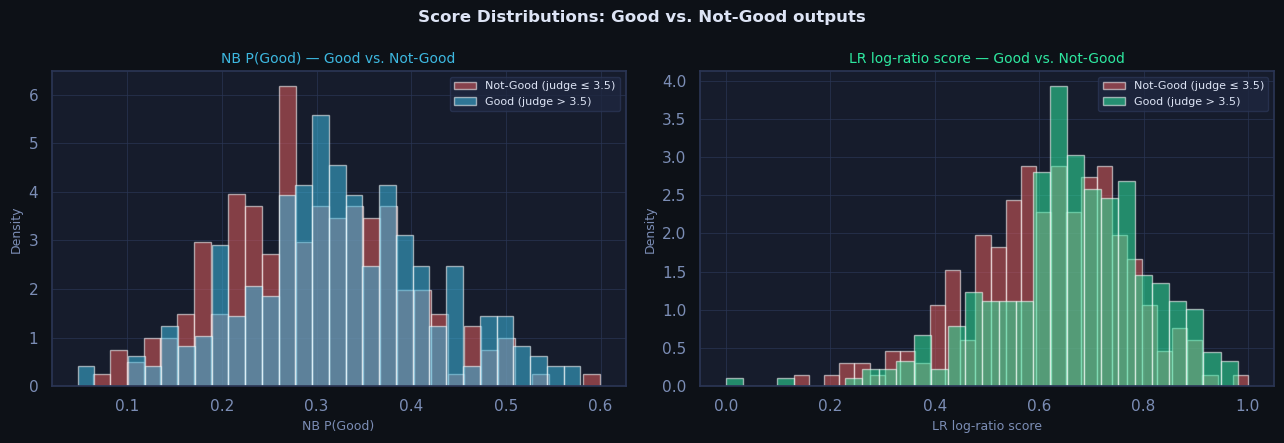

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor="#0d1117")
fig.suptitle("Score Distributions: Good vs. Not-Good outputs",
             fontsize=12, color="#dde4f5", fontweight="bold")

good = df[df["judge_mean"] > 3.5]
bad  = df[df["judge_mean"] <= 3.5]
print(f"Good (judge > 3.5): {len(good)} prompts | Not-Good: {len(bad)} prompts")

for ax, (col, label, color) in zip(axes, [
    ("nb_p_good_loo",  "NB P(Good)",        C2),
    ("lr_gr_loo",      "LR log-ratio score", C3),
]):
    ax.set_facecolor("#161c2c")
    ax.hist(bad[col],  bins=30, alpha=0.55, color="#e05c5c", label="Not-Good (judge ≤ 3.5)", density=True)
    ax.hist(good[col], bins=30, alpha=0.55, color=color,     label="Good (judge > 3.5)",     density=True)
    ax.set_xlabel(label, fontsize=9, color="#7b8db5")
    ax.set_ylabel("Density", fontsize=9, color="#7b8db5")
    ax.set_title(f"{label} — Good vs. Not-Good", fontsize=10, color=color)
    ax.legend(fontsize=8, facecolor="#1e2740", edgecolor="#2a3554", labelcolor="#dde4f5")
    for spine in ax.spines.values():
        spine.set_edgecolor("#2a3554")

plt.tight_layout()
plt.savefig("results/distributions.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

## Key takeaways

| Metric | Value | Meaning |
|--------|-------|----------|
| Best Pearson r | **0.2047** (LR LOO) | Moderate positive correlation with judge |
| Best pairwise accuracy | **56.6%** (LR LOO) | Correctly ranks 56.6% of prompt pairs |
| Variance explained (r²) | **4.2%** | Coherence alone explains little — quality matters more |
| Strongest single feature | s1_weighted (r=0.2129) | Text↔Image coherence, quality-weighted |

**Why LR beats NB and WTSAS:**
- WTSAS reduces 3D coherence → 1 number, losing discriminative information
- NB assumes s1_w, s2_w, s3_w are independent (they're not)
- LR models the full joint distribution difference between Good and Not-Good classes